In [1]:
# Module 0 — 挂载 Drive & 安装依赖 & 固定参数
from google.colab import drive
drive.mount('/content/drive')

!pip -q install pandas numpy scipy tqdm scikit-learn matplotlib

FS = 20.0
WIN_S = 30.0
HOP_S = 10.0

WIN_N = int(WIN_S * FS)   # 600
HOP_N = int(HOP_S * FS)   # 200

print("FS:", FS, "WIN_N:", WIN_N, "HOP_N:", HOP_N)

Mounted at /content/drive
FS: 20.0 WIN_N: 600 HOP_N: 200


In [2]:
# Module 1 — 路径、类别映射、扫描你的 EIP 文件
from pathlib import Path
import re
import pandas as pd

# ====== 你的 EIP 数据目录：请改成你自己的 ======
BASE = Path('/content/drive/MyDrive')
EIP_DIR = BASE / 'breathing_captures'

assert EIP_DIR.exists(), f"找不到目录: {EIP_DIR}"

# ====== 5类映射（按你文件名关键词）======
LABEL_MAP = {
    'healthy': 0,
    'apnea': 1,
    'pneumonia': 2,
    'bronchiolitis': 3,
    'uao': 4
}
IDX2LABEL = {v:k for k,v in LABEL_MAP.items()}
NUM_CLASSES = len(LABEL_MAP)

def infer_label_from_name(filename: str):
    name = filename.lower()
    for k, v in LABEL_MAP.items():
        if k in name:
            return v, k
    return None, None

# ====== 扫描文件：优先使用 npy；若没有 npy，使用 csv ======
npy_files = sorted(EIP_DIR.glob('*.npy'))
csv_files = sorted(EIP_DIR.glob('*.csv'))

# 建一个 basename -> path 的索引，方便配对
npy_dict = {p.stem: p for p in npy_files}
csv_dict = {p.stem: p for p in csv_files}

stems = sorted(set(npy_dict.keys()) | set(csv_dict.keys()))

rows = []
for stem in stems:
    # 优先 npy
    p_npy = npy_dict.get(stem, None)
    p_csv = csv_dict.get(stem, None)

    label_idx, label_name = infer_label_from_name(stem)
    if label_idx is None:
        # 文件名不含关键词就跳过（避免混入别的文件）
        continue

    rows.append({
        'session_id': stem,                     # 以文件名作为 session id（split 用它）
        'label_idx': label_idx,
        'label_name': label_name,
        'path_npy': str(p_npy) if p_npy else '',
        'path_csv': str(p_csv) if p_csv else ''
    })

df_sessions = pd.DataFrame(rows).sort_values(['label_idx', 'session_id']).reset_index(drop=True)

print("Found sessions:", len(df_sessions))
print(df_sessions['label_name'].value_counts())
df_sessions.head()


Found sessions: 39
label_name
pneumonia        9
uao              8
apnea            8
healthy          7
bronchiolitis    7
Name: count, dtype: int64


,session_id,label_idx,label_name,path_npy,path_csv
0,breathing_20251112_163607_healthy,0,healthy,/content/drive/MyDrive/breathing_captures/brea...,/content/drive/MyDrive/breathing_captures/brea...
1,breathing_20260112_134747_healthy,0,healthy,/content/drive/MyDrive/breathing_captures/brea...,/content/drive/MyDrive/breathing_captures/brea...
2,breathing_20260112_135247_healthy,0,healthy,/content/drive/MyDrive/breathing_captures/brea...,/content/drive/MyDrive/breathing_captures/brea...
3,breathing_20260112_135747_healthy,0,healthy,/content/drive/MyDrive/breathing_captures/brea...,/content/drive/MyDrive/breathing_captures/brea...
4,breathing_20260112_143111_healthy,0,healthy,/content/drive/MyDrive/breathing_captures/brea...,/content/drive/MyDrive/breathing_captures/brea...


In [3]:
# Module 2 — 读取 EIP 信号（支持 npy / csv）
import numpy as np
import pandas as pd

def load_eip_from_npy(path_npy: str):
    x = np.load(path_npy)
    x = np.asarray(x).squeeze()
    if x.ndim != 1:
        raise ValueError(f"npy 不是 1D 序列: {path_npy}, shape={x.shape}")
    return x.astype(np.float32)

def _pick_signal_column(df: pd.DataFrame):
    # 常见列名猜测
    candidates = ['eip', 'signal', 'value', 'adc', 'y', 'resp', 'wave']
    lower_cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        for lc, orig in lower_cols.items():
            if cand in lc:
                return orig
    # 找不到就用最后一列（很多导出就是 time + value）
    return df.columns[-1]

def _estimate_fs_from_time_col(df: pd.DataFrame):
    # 如果有时间列，估计 fs
    time_candidates = ['t', 'time', 'sec', 'seconds', 'timestamp']
    lower_cols = {c.lower(): c for c in df.columns}
    time_col = None
    for cand in time_candidates:
        for lc, orig in lower_cols.items():
            if cand == lc or cand in lc:
                time_col = orig
                break
        if time_col:
            break
    if time_col is None:
        return None

    t = pd.to_numeric(df[time_col], errors='coerce').to_numpy()
    t = t[np.isfinite(t)]
    if len(t) < 10:
        return None
    dt = np.diff(t)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    if len(dt) == 0:
        return None
    fs = 1.0 / np.median(dt)
    return float(fs)

def load_eip_from_csv(path_csv: str, fs_manual: float | None = None):
    df = pd.read_csv(path_csv)
    sig_col = _pick_signal_column(df)
    x = pd.to_numeric(df[sig_col], errors='coerce').to_numpy()
    x = x[np.isfinite(x)].astype(np.float32)

    fs_est = _estimate_fs_from_time_col(df)
    fs = fs_manual if fs_manual is not None else fs_est
    return x, fs

def load_session_signal(row, fs_manual: float | None = None):
    """
    row: df_sessions 的一行
    返回: x (float32 1D), fs (float or None), src ('npy'/'csv')
    """
    if isinstance(row.get('path_npy', ''), str) and row['path_npy']:
        return load_eip_from_npy(row['path_npy']), fs_manual, 'npy'
    elif isinstance(row.get('path_csv', ''), str) and row['path_csv']:
        x, fs = load_eip_from_csv(row['path_csv'], fs_manual=fs_manual)
        return x, fs, 'csv'
    else:
        raise FileNotFoundError("该 session 没有 npy/csv 路径")


In [4]:
# Module 3 — EIP 预处理（去趋势 + 低频带通 + 归一化）
import numpy as np
from scipy import signal

def detrend_1d(x: np.ndarray):
    # 线性去趋势（比单纯减均值更稳）
    return signal.detrend(x, type='linear').astype(np.float32)

def butter_bandpass_filter(x: np.ndarray, fs: float, hp_hz=0.05, lp_hz=2.0, order=4):
    if fs is None:
        raise ValueError("需要 fs 才能做滤波。请在 load 时传 fs_manual，或确保 csv 有 time 列可估计 fs。")

    nyq = 0.5 * fs
    hp = max(hp_hz / nyq, 1e-6)
    lp = min(lp_hz / nyq, 0.999999)

    if hp >= lp:
        raise ValueError(f"滤波参数不合法：hp={hp_hz}Hz, lp={lp_hz}Hz, fs={fs}")

    b, a = signal.butter(order, [hp, lp], btype='bandpass')
    y = signal.filtfilt(b, a, x).astype(np.float32)
    return y

def zscore(x: np.ndarray, eps=1e-8):
    mu = float(np.mean(x))
    sd = float(np.std(x))
    return ((x - mu) / (sd + eps)).astype(np.float32)

def robust_norm(x: np.ndarray, eps=1e-8):
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + eps
    return ((x - med) / mad).astype(np.float32)

import numpy as np
from scipy import signal

def bandpass_sos(x, fs, hp_hz=0.05, lp_hz=2.0, order=4):
    nyq = 0.5 * fs
    hp = max(hp_hz / nyq, 1e-6)
    lp = min(lp_hz / nyq, 0.999999)
    sos = signal.butter(order, [hp, lp], btype='bandpass', output='sos')
    padlen = int(min(len(x)-1, max(3*fs, 100)))  # ~3s or 100 samples
    return signal.sosfiltfilt(sos, x, padtype='odd', padlen=padlen).astype(np.float32)

def trim_edges(x, fs, trim_s=5.0):
    n = int(trim_s * fs)
    if len(x) > 2*n:
        return x[n:-n]
    return x

def quantile_norm(x, q=0.95, clip=1.5, eps=1e-8):
    scale = np.quantile(np.abs(x), q) + eps
    y = x / scale
    y = np.clip(y, -clip, clip)
    return y.astype(np.float32)

def preprocess_eip(
    x: np.ndarray,
    fs: float,
    drop_s=5.0,     # 丢弃启动段
    q=0.95,          # 95% 幅度对齐到 1
    clip=1.5
):
    x = x.astype(np.float32)

    # 1) 轻量去趋势（不再 bandpass）
    x = signal.detrend(x, type='linear')

    # 2) 丢弃前 N 秒（系统启动 / 采集不稳）
    n_drop = int(drop_s * fs)
    if len(x) > n_drop:
        x = x[n_drop:]

    # 3) 分位数幅度归一化（比 z-score 稳得多）
    scale = np.quantile(np.abs(x), q) + 1e-8
    x = x / scale
    x = np.clip(x, -clip, clip)

    return x.astype(np.float32)



In [5]:
# Module 4 — 生成 session-level manifest（并做一次预处理 sanity check）
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path

# ===== 你必须设置：EIP 采样率 fs（如果 csv 没有时间列）=====
FS_MANUAL = 20.0   # <<< 改成你的实际采样率（例如 20/50/100 Hz）

# ===== 输出目录 =====
OUT_BASE = BASE / 'eip_prepared'
OUT_BASE.mkdir(parents=True, exist_ok=True)

PROC_DIR = OUT_BASE / 'processed_sessions'
PROC_DIR.mkdir(parents=True, exist_ok=True)

manifest_rows = []

for _, row in tqdm(df_sessions.iterrows(), total=len(df_sessions)):
    x, fs, src = load_session_signal(row, fs_manual=FS_MANUAL)
    fs = FS_MANUAL if fs is None else fs

    # 预处理整段（可选，但推荐先存下来）
    x_proc = preprocess_eip(
    x, fs=fs,
    drop_s=5.0,   # 丢掉前 5 秒启动瞬态（你也可以先用 10）
    q=0.95,        # 95% 幅度缩放到 1
    clip=1.5       # 允许超出到 ±1.5
    )


    # 保存预处理后的 5-min session（npy）
    out_path = PROC_DIR / f"{row['session_id']}_proc.npy"
    np.save(out_path, x_proc.astype(np.float32))

    duration_s = len(x_proc) / fs

    manifest_rows.append({
        'session_id': row['session_id'],
        'label_idx': int(row['label_idx']),
        'label_name': row['label_name'],
        'fs': float(fs),
        'n_samples': int(len(x_proc)),
        'duration_s': float(duration_s),
        'src': src,
        'path_raw_npy': row['path_npy'],
        'path_raw_csv': row['path_csv'],
        'path_proc_npy': str(out_path),
    })

df_manifest = pd.DataFrame(manifest_rows)
MANIFEST_PATH = OUT_BASE / 'manifest_eip_sessions.csv'
df_manifest.to_csv(MANIFEST_PATH, index=False)

print("Saved manifest:", MANIFEST_PATH)
print(df_manifest['label_name'].value_counts())
df_manifest.head()


100%|██████████| 39/39 [00:28<00:00,  1.36it/s]


Saved manifest: /content/drive/MyDrive/eip_prepared/manifest_eip_sessions.csv
label_name
pneumonia        9
uao              8
apnea            8
healthy          7
bronchiolitis    7
Name: count, dtype: int64


,session_id,label_idx,label_name,fs,n_samples,duration_s,src,path_raw_npy,path_raw_csv,path_proc_npy
0,breathing_20251112_163607_healthy,0,healthy,20.0,5900,295.0,npy,/content/drive/MyDrive/breathing_captures/brea...,/content/drive/MyDrive/breathing_captures/brea...,/content/drive/MyDrive/eip_prepared/processed_...
1,breathing_20260112_134747_healthy,0,healthy,20.0,5900,295.0,npy,/content/drive/MyDrive/breathing_captures/brea...,/content/drive/MyDrive/breathing_captures/brea...,/content/drive/MyDrive/eip_prepared/processed_...
2,breathing_20260112_135247_healthy,0,healthy,20.0,5900,295.0,npy,/content/drive/MyDrive/breathing_captures/brea...,/content/drive/MyDrive/breathing_captures/brea...,/content/drive/MyDrive/eip_prepared/processed_...
3,breathing_20260112_135747_healthy,0,healthy,20.0,5900,295.0,npy,/content/drive/MyDrive/breathing_captures/brea...,/content/drive/MyDrive/breathing_captures/brea...,/content/drive/MyDrive/eip_prepared/processed_...
4,breathing_20260112_143111_healthy,0,healthy,20.0,5900,295.0,npy,/content/drive/MyDrive/breathing_captures/brea...,/content/drive/MyDrive/breathing_captures/brea...,/content/drive/MyDrive/eip_prepared/processed_...


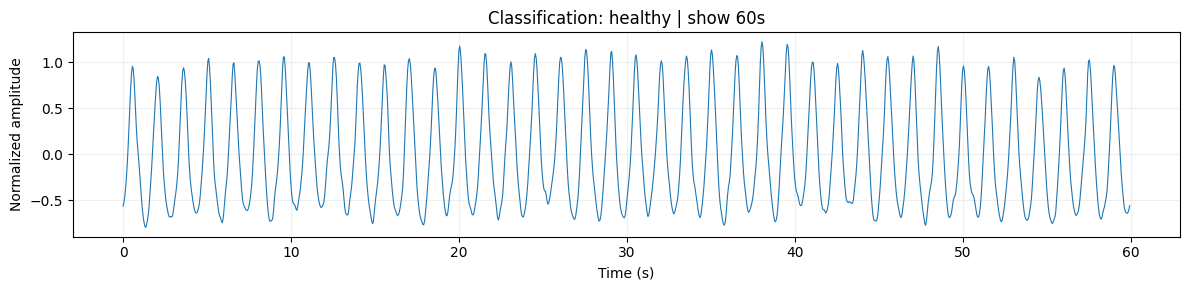

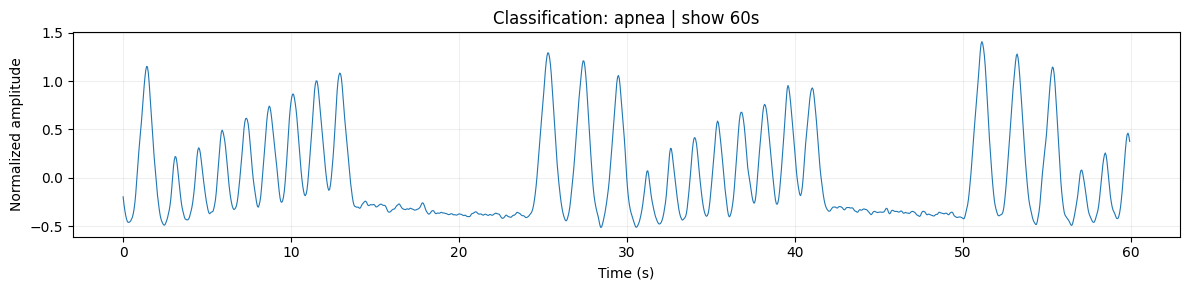

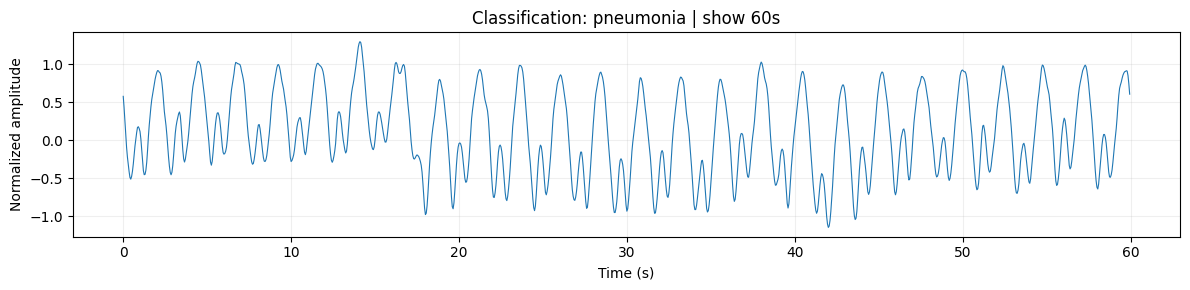

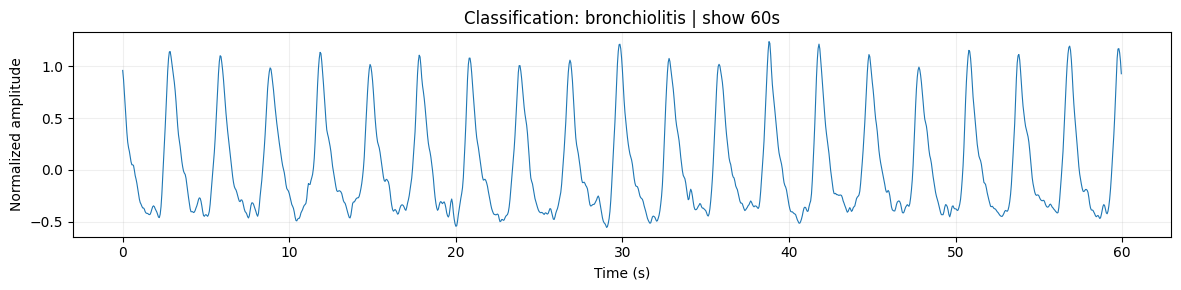

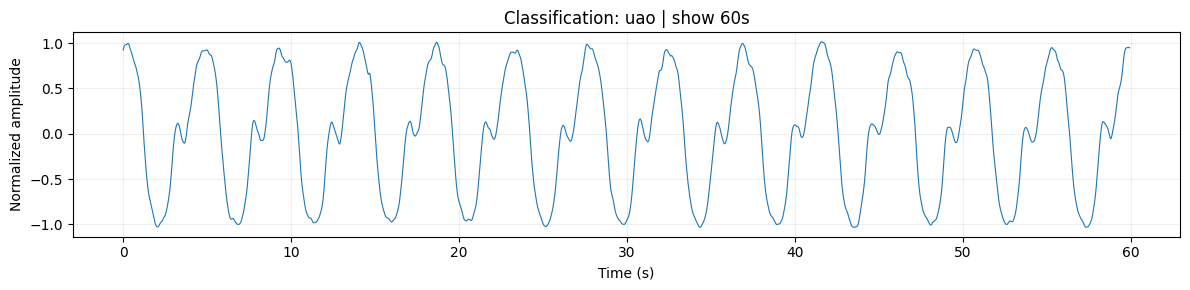

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_one_session(df_manifest, label_name=None, seed=0, seconds=60, win_seed=None):
    sub = df_manifest if label_name is None else df_manifest[df_manifest['label_name'] == label_name]
    assert len(sub) > 0, f"没有找到 label={label_name} 的样本"

    # ===== 1. session 固定（完全不变）=====
    row = sub.sample(1, random_state=seed).iloc[0]
    x = np.load(row['path_proc_npy'])
    fs = row['fs']

    win_len = int(seconds * fs)
    total_len = len(x)
    assert total_len >= win_len

    # ===== 2. 60 秒窗口起点可换 =====
    rng = np.random.default_rng(win_seed)
    max_start = total_len - win_len
    start = rng.integers(0, max_start + 1)
    end = start + win_len

    seg = x[start:end]
    t = np.arange(win_len) / fs

    # ===== 3. 画图 =====
    plt.figure(figsize=(12,3))
    plt.plot(t, seg, linewidth=0.8)
    plt.title(
        f"Classification: {row['label_name']} | "
        f"show {seconds}s"
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Normalized amplitude")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


# 示例：每类画一条
for name in ['healthy','apnea','pneumonia','bronchiolitis','uao']:
    plot_one_session(df_manifest, label_name=name, seed=2, seconds=60)


In [7]:
# Module 6 — 生成窗口 manifest + “按 session”划分 train/val
# 规则：每类前2个 session -> train，其余全部 -> val（无泄露）

import numpy as np
import pandas as pd
from pathlib import Path

OUT_BASE = Path('/content/drive/MyDrive/eip_prepared')
SAMPLE_MANIFEST_PATH = OUT_BASE / 'manifest_eip_windows_trainval.csv'

df = df_manifest.copy()

TRAIN_SESS_PER_CLASS = 2
RANDOM_SEED = 2025
rng = np.random.default_rng(RANDOM_SEED)

def make_windows_for_session(session_row):
    x = np.load(session_row['path_proc_npy']).astype(np.float32)
    fs = float(session_row['fs'])
    assert abs(fs - FS) < 1e-6, f"fs 不一致：{fs} != {FS}"

    total = len(x)
    rows = []
    start = 0
    idx = 0
    while start + WIN_N <= total:
        end = start + WIN_N
        rows.append({
            'session_id': session_row['session_id'],
            'label_idx': int(session_row['label_idx']),
            'label_name': session_row['label_name'],
            'fs': fs,
            'start_idx': start,
            'end_idx': end,
            'win_idx': idx,
            'path_proc_npy': session_row['path_proc_npy'],
        })
        start += HOP_N
        idx += 1
    return rows

# ============================================================
# 1) Session-level split：每类前2条 train，其余全部 val
# ============================================================
counts = df.groupby('label_name')['session_id'].nunique().sort_values(ascending=False)
print("Sessions per class:\n", counts)

bad = counts[counts < TRAIN_SESS_PER_CLASS]
if len(bad) > 0:
    raise ValueError(f"以下类别 session 数不足（需要 >= {TRAIN_SESS_PER_CLASS}）：\n{bad}")

session_split_rows = []
for label, sub in df.groupby('label_name'):
    sessions = sub['session_id'].unique().tolist()
    rng.shuffle(sessions)  # 想固定顺序就删掉这一行

    train_sess = sessions[:TRAIN_SESS_PER_CLASS]
    val_sess   = sessions[TRAIN_SESS_PER_CLASS:]  # 剩下全部 val

    for sid in train_sess:
        session_split_rows.append({'session_id': sid, 'split': 'train'})
    for sid in val_sess:
        session_split_rows.append({'session_id': sid, 'split': 'val'})

df_session_split = pd.DataFrame(session_split_rows)

# merge 回 df（每条 session 带上 split）
df = df.merge(df_session_split, on='session_id', how='left')

# 安全检查：不应该有缺失 split
if df['split'].isna().any():
    missing = df[df['split'].isna()][['session_id','label_name']].drop_duplicates()
    raise RuntimeError(f"有 session 没有分到 train/val：\n{missing}")

print("\nSession split check (sessions count):")
print(df.groupby(['split','label_name'])['session_id'].nunique())

# overlap 检查（必须为 0）
train_sessions = set(df[df['split']=='train']['session_id'].unique())
val_sessions   = set(df[df['split']=='val']['session_id'].unique())
print("\nOverlap sessions (must be empty):", train_sessions & val_sessions)

# ============================================================
# 2) 对所有 session 生成 windows，并继承 session 的 split
# ============================================================
all_rows = []
for _, r in df.iterrows():
    rows = make_windows_for_session(r)
    for rr in rows:
        rr['split'] = r['split']   # 继承 session-level split
    all_rows.extend(rows)

df_windows = pd.DataFrame(all_rows)

df_windows.to_csv(SAMPLE_MANIFEST_PATH, index=False)

print("\nSaved:", SAMPLE_MANIFEST_PATH)
print("Windows split counts:\n", df_windows['split'].value_counts())
print("\nWindows per class:\n", df_windows.groupby(['split','label_name']).size())

df_windows.head()


Sessions per class:
 label_name
pneumonia        9
apnea            8
uao              8
healthy          7
bronchiolitis    7
Name: session_id, dtype: int64

Session split check (sessions count):
split  label_name   
train  apnea            2
       bronchiolitis    2
       healthy          2
       pneumonia        2
       uao              2
val    apnea            6
       bronchiolitis    5
       healthy          5
       pneumonia        7
       uao              6
Name: session_id, dtype: int64

Overlap sessions (must be empty): set()

Saved: /content/drive/MyDrive/eip_prepared/manifest_eip_windows_trainval.csv
Windows split counts:
 split
val      783
train    270
Name: count, dtype: int64

Windows per class:
 split  label_name   
train  apnea             54
       bronchiolitis     54
       healthy           54
       pneumonia         54
       uao               54
val    apnea            162
       bronchiolitis    135
       healthy          135
       pneumonia        1

,session_id,label_idx,label_name,fs,start_idx,end_idx,win_idx,path_proc_npy,split
0,breathing_20251112_163607_healthy,0,healthy,20.0,0,600,0,/content/drive/MyDrive/eip_prepared/processed_...,val
1,breathing_20251112_163607_healthy,0,healthy,20.0,200,800,1,/content/drive/MyDrive/eip_prepared/processed_...,val
2,breathing_20251112_163607_healthy,0,healthy,20.0,400,1000,2,/content/drive/MyDrive/eip_prepared/processed_...,val
3,breathing_20251112_163607_healthy,0,healthy,20.0,600,1200,3,/content/drive/MyDrive/eip_prepared/processed_...,val
4,breathing_20251112_163607_healthy,0,healthy,20.0,800,1400,4,/content/drive/MyDrive/eip_prepared/processed_...,val


In [8]:
# Module 7 - Dataset + DataLoader (训练集)
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from collections import OrderedDict
import random

# ---- 可复现（可选，但推荐）----
SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MANIFEST_WIN = '/content/drive/MyDrive/eip_prepared/manifest_eip_windows_trainval.csv'
df_win = pd.read_csv(MANIFEST_WIN)

# ===== 类别映射（从 df_win 自动推断）=====
labels_sorted = sorted(df_win[['label_idx','label_name']].drop_duplicates().values, key=lambda x: x[0])
IDX2CLS = {int(i): str(n) for i, n in labels_sorted}
CLS2IDX = {v: k for k, v in IDX2CLS.items()}
NUM_CLASSES = len(IDX2CLS)

print("Classes:", IDX2CLS)

df_tr = df_win[df_win['split']=='train'].reset_index(drop=True)
df_va = df_win[df_win['split']=='val'].reset_index(drop=True)

print("Train windows:", len(df_tr), "Val windows:", len(df_va))
print("Train sessions:", df_tr['session_id'].nunique(), "Val sessions:", df_va['session_id'].nunique())

class EIPWindowDataset(Dataset):
    def __init__(self, df, train=True, cache_size=128, aug_noise_std=0.02, aug_gain=0.15):
        self.df = df
        self.train = train
        self.cache = OrderedDict()
        self.cache_size = int(cache_size)
        self.aug_noise_std = float(aug_noise_std)
        self.aug_gain = float(aug_gain)

    def _get_session(self, path):
        arr = self.cache.pop(path, None)
        if arr is not None:
            self.cache[path] = arr
            return arr
        arr = np.load(path).astype(np.float32)
        self.cache[path] = arr
        if len(self.cache) > self.cache_size:
            self.cache.popitem(last=False)
        return arr

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        x_full = self._get_session(r['path_proc_npy'])
        s0, s1 = int(r['start_idx']), int(r['end_idx'])
        x = x_full[s0:s1].copy()  # [T]

        # 轻量增强：幅度缩放 + 噪声（只在 train）
        if self.train:
            gain = 1.0 + (2*np.random.rand()-1.0) * self.aug_gain
            x *= gain
            x += np.random.randn(*x.shape).astype(np.float32) * self.aug_noise_std

        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # [1, T]
        y = torch.tensor(int(r['label_idx']), dtype=torch.long)
        return x, y

bs = 32
train_ds = EIPWindowDataset(df_tr, train=True,  cache_size=256, aug_noise_std=0.02, aug_gain=0.15)
val_ds   = EIPWindowDataset(df_va, train=False, cache_size=256)

train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True, drop_last=True,
                          num_workers=0, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_ds, batch_size=bs, shuffle=False,
                          num_workers=0, pin_memory=torch.cuda.is_available())

Classes: {0: 'healthy', 1: 'apnea', 2: 'pneumonia', 3: 'bronchiolitis', 4: 'uao'}
Train windows: 270 Val windows: 783
Train sessions: 10 Val sessions: 29


In [9]:
# Module 8 - ResNet1D + BiLSTM 分类模型
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResBlock1D(nn.Module):
    def __init__(self, c_in, c_out, stride=1, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, kernel_size=7, stride=stride, padding=3, bias=False)
        self.bn1   = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, kernel_size=7, stride=1, padding=3, bias=False)
        self.bn2   = nn.BatchNorm1d(c_out)
        self.drop  = nn.Dropout(dropout)

        self.skip = None
        if stride != 1 or c_in != c_out:
            self.skip = nn.Sequential(
                nn.Conv1d(c_in, c_out, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(c_out),
            )

    def forward(self, x):
        identity = x
        out = self.conv1(x); out = self.bn1(out); out = F.relu(out)
        out = self.drop(out)
        out = self.conv2(out); out = self.bn2(out)

        if self.skip is not None:
            identity = self.skip(identity)

        out = F.relu(out + identity)
        return out

class ResNetLSTM1D(nn.Module):
    """
    输入: [B, 1, 600]
    输出: [B, num_classes]
    """
    def __init__(self, num_classes=5, dropout=0.2, lstm_hidden=64):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=9, stride=2, padding=4, bias=False),  # 600 -> 300
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )

        self.layer1 = ResBlock1D(32, 64, stride=2, dropout=dropout)  # 300 -> 150
        self.layer2 = ResBlock1D(64, 128, stride=2, dropout=dropout) # 150 -> 75
        self.layer3 = ResBlock1D(128, 128, stride=1, dropout=dropout)

        # LSTM over time axis
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(2*lstm_hidden, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: [B,1,T]
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        # -> [B, T', C] for LSTM
        x = x.transpose(1, 2)  # [B, T', 128]
        out, (hn, cn) = self.lstm(x)  # out: [B, T', 2H]

        # 用最后时刻特征（也可用 mean pooling）
        feat = out[:, -1, :]  # [B, 2H]
        logits = self.head(feat)
        return logits

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNetLSTM1D(num_classes=NUM_CLASSES, dropout=0.25, lstm_hidden=64).to(device)
print(model)

ResNetLSTM1D(
  (stem): Sequential(
    (0): Conv1d(1, 32, kernel_size=(9,), stride=(2,), padding=(4,), bias=False)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer1): ResBlock1D(
    (conv1): Conv1d(32, 64, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (drop): Dropout(p=0.25, inplace=False)
    (skip): Sequential(
      (0): Conv1d(32, 64, kernel_size=(1,), stride=(2,), bias=False)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer2): ResBlock1D(
    (conv1): Conv1d(64, 128, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
    (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1,

In [10]:
# Module 9 - 训练
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score

# ===== 计算 class weights（基于 train set）=====
train_labels = df_tr['label_idx'].values
counts = np.bincount(train_labels, minlength=NUM_CLASSES)
weights = 1.0 / (counts + 1e-6)
weights = weights / weights.mean()
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print("Class counts:", counts)
print("Class weights:", weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)

def run_epoch(loader, train=True):
    model.train(train)
    losses = []
    y_true, y_pred = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        if train:
            optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        losses.append(loss.item())
        pred = torch.argmax(logits, dim=1)

        y_true.extend(y.detach().cpu().numpy().tolist())
        y_pred.extend(pred.detach().cpu().numpy().tolist())

    acc = accuracy_score(y_true, y_pred)
    return float(np.mean(losses)), float(acc)

# ===== 训练循环 + early stopping =====
best_val_acc = -1
best_state = None
patience = 10
pat_cnt = 0
EPOCHS = 30

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader, train=False)

    print(f"Epoch {epoch:03d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.3f}")

    if va_acc > best_val_acc + 1e-4:
        best_val_acc = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        pat_cnt = 0
    else:
        pat_cnt += 1
        if pat_cnt >= patience:
            print("Early stopping.")
            break

# 恢复最佳模型
if best_state is not None:
    model.load_state_dict(best_state)

print("Best val acc:", best_val_acc)

Class counts: [54 54 54 54 54]
Class weights: [1. 1. 1. 1. 1.]
Epoch 001 | train loss 1.5272 acc 0.367 | val loss 1.6110 acc 0.172
Epoch 002 | train loss 1.1275 acc 0.805 | val loss 1.7633 acc 0.172
Epoch 003 | train loss 0.6903 acc 0.805 | val loss 2.0314 acc 0.289
Epoch 004 | train loss 0.3994 acc 0.879 | val loss 1.8585 acc 0.465
Epoch 005 | train loss 0.2618 acc 0.953 | val loss 1.1353 acc 0.686
Epoch 006 | train loss 0.1397 acc 0.980 | val loss 0.4625 acc 0.858
Epoch 007 | train loss 0.0697 acc 0.988 | val loss 0.4586 acc 0.884
Epoch 008 | train loss 0.0182 acc 1.000 | val loss 0.3808 acc 0.917
Epoch 009 | train loss 0.0138 acc 1.000 | val loss 0.4671 acc 0.899
Epoch 010 | train loss 0.0081 acc 1.000 | val loss 0.3914 acc 0.917
Epoch 011 | train loss 0.0057 acc 1.000 | val loss 0.5165 acc 0.883
Epoch 012 | train loss 0.0045 acc 1.000 | val loss 0.4727 acc 0.898
Epoch 013 | train loss 0.0024 acc 1.000 | val loss 0.3993 acc 0.912
Epoch 014 | train loss 0.0023 acc 1.000 | val loss 0.

Confusion Matrix (counts):
 [[125   2   8   0   0]
 [  0 155   1   5   1]
 [  0  12 165   1  11]
 [  0   3   1 131   0]
 [  0   0   0   0 162]]
               precision    recall  f1-score   support

      healthy      1.000     0.926     0.962       135
        apnea      0.901     0.957     0.928       162
    pneumonia      0.943     0.873     0.907       189
bronchiolitis      0.956     0.970     0.963       135
          uao      0.931     1.000     0.964       162

     accuracy                          0.943       783
    macro avg      0.946     0.945     0.945       783
 weighted avg      0.944     0.943     0.942       783



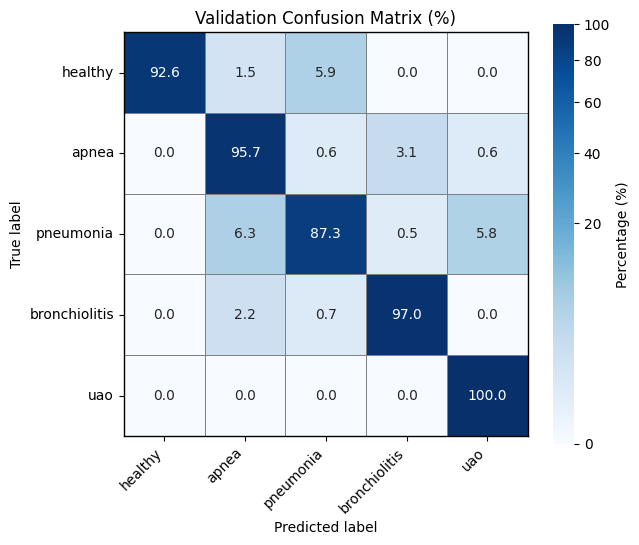

In [16]:
# Module 10 - Confusion Matrix + 分类报告
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import PowerNorm

def apnea_like_inside_window(
    x_1d: np.ndarray,
    fs: float,
    low_thr_quantile: float = 0.20,
    min_apnea_sec: float = 10.0
) -> bool:
    x = x_1d.astype(np.float32)
    x = x - np.median(x)

    thr = np.quantile(np.abs(x), low_thr_quantile)
    low = (np.abs(x) <= thr).astype(np.int32)
    best = cur = 0
    for v in low:
        if v:
            cur += 1
            best = max(best, cur)
        else:
            cur = 0

    return best >= int(min_apnea_sec * fs)


# ========== 推理：收集 y_true / y_pred / probs ==========
model.eval()
y_true, y_pred = [], []
probs_all = []
xwin_all = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)                          # x: [B, 1, T]
        logits = model(x)                         # [B, C]
        probs = torch.softmax(logits, dim=1)      # [B, C]

        pred = torch.argmax(probs, dim=1).cpu().numpy()
        y_pred.extend(pred.tolist())
        y_true.extend(y.numpy().tolist())

        probs_all.append(probs.cpu().numpy())
        xwin_all.append(x.squeeze(1).cpu().numpy())  # [B, T]

probs_all = np.concatenate(probs_all, axis=0)  # [N, C]
xwin_all  = np.concatenate(xwin_all, axis=0)   # [N, T]
y_true = np.array(y_true, dtype=int)
y_pred = np.array(y_pred, dtype=int)

apnea_idx = CLS2IDX.get('apnea', None)
PENALTY = 0.015   # 0.2~0.5 之间试；越小越严格（越不容易输出 apnea）
LOW_Q   = 0.1   # abs阈值分位数（越小越严格）
MIN_APNEA_SEC = 10.0

# 只对“预测为 apnea”的样本做 gate；不满足则降低 P(apnea) 再重新 argmax
for i in range(len(y_pred)):
    if y_pred[i] == apnea_idx:
        ok = apnea_like_inside_window(
            xwin_all[i],
            fs=float(FS),
            low_thr_quantile=LOW_Q,
            min_apnea_sec=MIN_APNEA_SEC
        )
        if not ok:
            probs_all[i, apnea_idx] *= PENALTY
            y_pred[i] = int(np.argmax(probs_all[i]))

# ========== 混淆矩阵（counts + %）与分类报告 ==========
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
print("Confusion Matrix (counts):\n", cm)

target_names = [IDX2CLS[i] for i in range(NUM_CLASSES)]
print(classification_report(y_true, y_pred, target_names=target_names, digits=3))

# 行归一化 -> 百分比
cm_percent = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1.0)
cm_percent = np.round(cm_percent * 100, 1)

from matplotlib.colors import PowerNorm

plt.figure(figsize=(6.5, 5.5))

# 温和拉开低值（1–10%）的对比度
norm = PowerNorm(gamma=0.4, vmin=0, vmax=100)

ax = sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    norm=norm,
    xticklabels=target_names,
    yticklabels=target_names,
    cbar_kws={"label": "Percentage (%)"},
    square=True,
    linewidths=0.5,
    linecolor="gray"
)

# ===== 强制显示四周边框 =====
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color("black")

# ===== 坐标轴文字 =====
ax.set_xticklabels(target_names, rotation=45, ha="right")
ax.set_yticklabels(target_names, rotation=0)
ax.set_aspect("equal")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation Confusion Matrix (%)")

plt.tight_layout()
plt.show()
